# Import thư viện và Load dữ liệu
Dataset có bao nhiêu dòng và cột?

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Thay đổi đường dẫn nếu cần
file_path = '../data/raw/house_buying_dec29th_2025.csv'
df = pd.read_csv(file_path)

print(f"Dataset có {df.shape[0]:,} dòng và {df.shape[1]} cột.")
display(df.head())

Dataset có 66,912 dòng và 11 cột.


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,196958,https://batdongsan.vn/ban-nha-nguyen-son-long-...,Bán nhà Nguyễn Sơn Long Biên- Dân trí Tuyệt vờ...,"Long Biên, Hà Nội",2,50.0,4.0,4.0,6.0,False,12500.0
1,196967,https://batdongsan.vn/ban-nha-hem-xe-hoi-4m-2-...,"BÁN NHÀ HẺM XE HƠI 4M, 2 MẶT TIỀN - 2 TẦNG , N...","Bình Chánh, Hồ Chí Minh",2,98.0,4.0,4.0,3.0,True,5500.0
2,196983,https://batdongsan.vn/o-to-ngu-nha-62m2-5-tang...,Ô TÔ NGỦ NHÀ – 62M² – 5 Tầng/4PN – Gần kdc CIT...,"Gò Vấp, Hồ Chí Minh",2,62.0,4.0,5.0,6.0,False,8740.0
3,196962,https://batdongsan.vn/ban-nha-phuc-loi-ngo-non...,Bán nhà Phúc Lợi - ngõ nông - ô tô vào nhà - t...,"Long Biên, Hà Nội",2,39.0,3.0,4.0,6.0,False,6500.0
4,196972,https://batdongsan.vn/tran-duy-hung-6-tang-tha...,TRẦN DUY HƯNG - 6 TẦNG THANG MÁY - NGÕ THÔNG D...,"Cầu Giấy, Hà Nội",2,45.0,3.0,3.0,7.0,True,16980.0


# Kiểm tra ý nghĩa và kiểu dữ liệu
Ý nghĩa và kiểu dữ liệu từng cột là gì?

In [21]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66912 entries, 0 to 66911
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 66912 non-null  int64  
 1   detail_url         66905 non-null  object 
 2   title              66912 non-null  object 
 3   location           66912 non-null  object 
 4   timeline_hours     66912 non-null  int64  
 5   area_m2            50344 non-null  float64
 6   bedrooms           55273 non-null  float64
 7   bathrooms          51548 non-null  float64
 8   floors             52278 non-null  float64
 9   frontage           66912 non-null  bool   
 10  price_million_vnd  64809 non-null  float64
dtypes: bool(1), float64(5), int64(2), object(3)
memory usage: 5.2+ MB


None

# Đánh giá Missing Values và Duplicates
Số lượng missing, tỷ lệ missing và dữ liệu trùng lặp?

In [22]:
print(f"Số lượng dòng trùng lặp (Duplicates): {df.duplicated().sum():,}")

missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

print("\nThống kê dữ liệu thiếu:")
display(missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False))

Số lượng dòng trùng lặp (Duplicates): 0

Thống kê dữ liệu thiếu:


,Missing Count,Missing Percentage (%)
area_m2,16568,24.760880
bathrooms,15364,22.961502
floors,14634,21.870516
bedrooms,11639,17.394488
price_million_vnd,2103,3.142934
detail_url,7,0.010462


# Khám phá Numerical Features
 Range của các biến số như thế nào? Có giá trị bất thường ban đầu không?

In [23]:
# Quan sát kỹ các giá trị min/max của Area, Bedrooms, Bathrooms, Floors, Price
display(df.describe().round(2))

,id,timeline_hours,area_m2,bedrooms,bathrooms,floors,price_million_vnd
count,66912.00,66912.00,50344.00,55273.00,51548.00,5.227800e+04,64809.00
mean,141092.73,8749.22,1377.98,4.43,4.30,1.477595e+04,13810.68
std,32545.27,6863.20,276334.66,4.50,4.62,3.377399e+06,35144.73
min,80084.00,2.00,1.00,1.00,1.00,0.000000e+00,0.00
25%,116152.75,3600.00,42.00,3.00,2.00,3.000000e+00,4600.00
50%,142310.00,7200.00,60.00,4.00,3.00,4.000000e+00,7000.00
75%,168691.50,8760.00,92.00,5.00,5.00,6.000000e+00,12800.00
max,197061.00,26280.00,62000000.00,127.00,127.00,7.722213e+08,989000.00


# Khám phá Categorical Features
Location có bao nhiêu category? Frontage có các giá trị nào?

In [30]:
categorical_cols = ['location', 'frontage']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- Thống kê cột '{col}' ---")
        unique_count = df[col].nunique(dropna=False)
        print(f"Số lượng category : {unique_count}")

        if unique_count <= 10:
            print("Chi tiết các giá trị và số lượng:")
            print(df[col].value_counts(dropna=False))
        else:
            print("Top 5 giá trị xuất hiện nhiều nhất:")
            print(df[col].value_counts(dropna=False).head(5))


--- Thống kê cột 'location' ---
Số lượng category : 280
Top 5 giá trị xuất hiện nhiều nhất:
location
Gò Vấp, Hồ Chí Minh      3441
Đống Đa, Hà Nội          3252
Tân Phú, Hồ Chí Minh     3247
Bình Tân, Hồ Chí Minh    3130
Long Biên, Hà Nội        3111
Name: count, dtype: int64

--- Thống kê cột 'frontage' ---
Số lượng category : 2
Chi tiết các giá trị và số lượng:
frontage
False    52086
True     14826
Name: count, dtype: int64


# Phân phối của biến mục tiêu (Price)
Price có phân phối như thế nào?

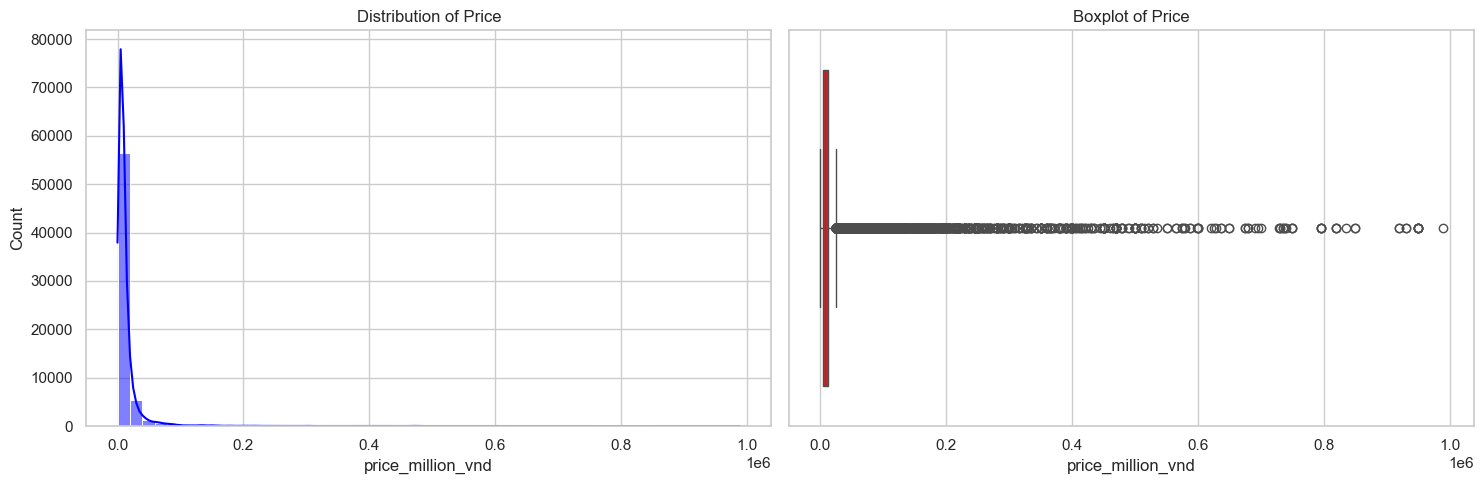

In [32]:
if 'price_million_vnd' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram
    sns.histplot(df['price_million_vnd'], bins=50, kde=True, color='blue', ax=axes[0])
    axes[0].set_title('Distribution of Price')

    # Boxplot để tìm Outlier
    sns.boxplot(x=df['price_million_vnd'], color='red', ax=axes[1])
    axes[1].set_title('Boxplot of Price')

    plt.tight_layout()
    plt.show()